In [1]:
from cresowlve.utils import read_json

benchmark = read_json("../experiments/data/task/chgk_en_benchmark.json")
domain_results = read_json("../experiments/data/task/chgk_benchmark_domain.json")
knowledge_results = read_json("../experiments/data/task/chgk_benchmark_knowledge.json")

results = read_json("results.json")
sub_results = [
    result for result in results
    if result["model_name"] in [
        "Llama-3.3-70B-Instruct",
        "Qwen3.5-397B-A17B",
        "GPT-4.1",
        "Qwen3-235B-A22B-Thinking",
        "DeepSeek-V3.2",
        "GPT-5.4",
        "Gemini-3-Flash",
        "Gemini-3.1-Pro",
    ] and result["thinking"] in [None, "medium", "adaptive"]
]

In [4]:
analysis_data = []

for result_info in sub_results:
    model_results = read_json(result_info["en_path"])
    model_name = result_info["model_name"]
    thinking = result_info.get("thinking")
    model_label = model_name if thinking is None else f"{model_name} ({thinking})"
    model_analysis_data = []
    for sample in model_results["data"]:
        domain_sample = next((item for item in domain_results["data"] if item["id"] == sample["id"]), None)
        knowledge_sample = next((item for item in knowledge_results["data"] if item["id"] == sample["id"]), None)
        model_analysis_data.append({
            "id": sample["id"],
            "model": model_label,
            "prediction": sample["gpt-4o_judge_match"],
            "num_domains": len(domain_sample["domains"]) if domain_sample else 0,
            "max_domain_semdis": domain_sample["max_domain_semdis"] if domain_sample else 0,
            "num_knowledge": len(knowledge_sample.get("knowledge", [])) if knowledge_sample else 0,
        })
    analysis_data.extend(model_analysis_data)

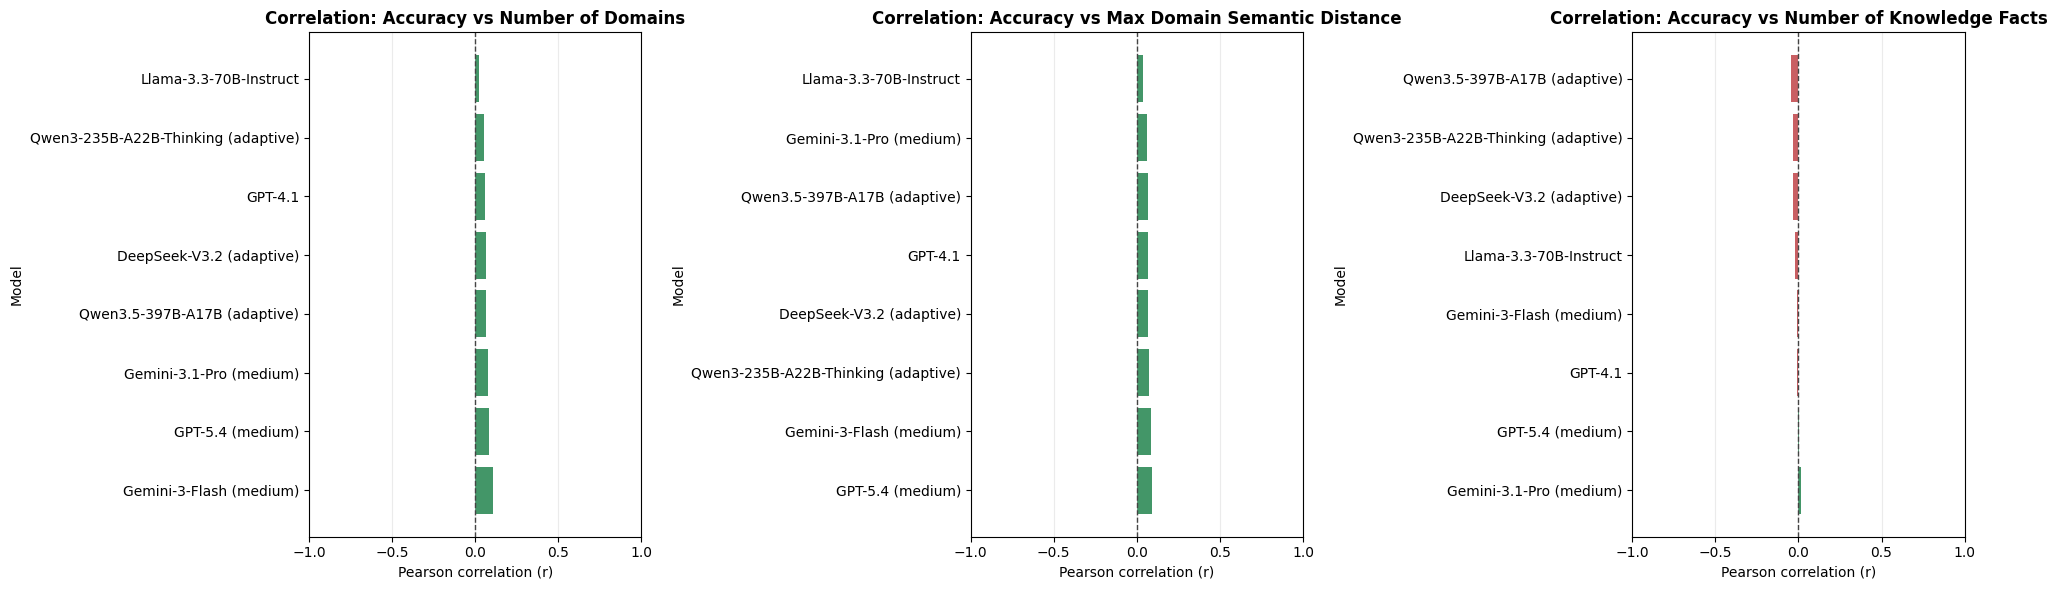

feature,max_domain_semdis,num_domains,num_knowledge
model,,,
DeepSeek-V3.2 (adaptive),0.068,0.066,-0.032
GPT-4.1,0.066,0.059,-0.007
GPT-5.4 (medium),0.093,0.084,0.006
Gemini-3-Flash (medium),0.083,0.108,-0.007
Gemini-3.1-Pro (medium),0.063,0.075,0.016
Llama-3.3-70B-Instruct,0.035,0.026,-0.018
Qwen3-235B-A22B-Thinking (adaptive),0.071,0.051,-0.035
Qwen3.5-397B-A17B (adaptive),0.065,0.067,-0.046


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = ["num_domains", "max_domain_semdis", "num_knowledge"]

df = pd.DataFrame(analysis_data).copy()
df["prediction"] = df["prediction"].astype(float)

corr_rows = []
for model_name, group in df.groupby("model"):
    for feature in feature_cols:
        corr = np.nan
        if group[feature].nunique() > 1 and group["prediction"].nunique() > 1:
            corr = group[feature].corr(group["prediction"])
        corr_rows.append({
            "model": model_name,
            "feature": feature,
            "correlation": corr,
        })

corr_df = pd.DataFrame(corr_rows).dropna(subset=["correlation"])
feature_title_map = {
    "num_domains": "Correlation: Accuracy vs Number of Domains",
    "max_domain_semdis": "Correlation: Accuracy vs Max Domain Semantic Distance",
    "num_knowledge": "Correlation: Accuracy vs Number of Knowledge Facts",
}

fig, axes = plt.subplots(1, len(feature_cols), figsize=(20, 6), sharex=True)
if len(feature_cols) == 1:
    axes = [axes]

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    feature_corr = corr_df[corr_df["feature"] == feature].sort_values("correlation", ascending=False)
    if feature_corr.empty:
        ax.set_title(feature_title_map[feature])
        ax.text(0.5, 0.5, "Not enough variation for correlation", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")
        continue

    colors = ["#2E8B57" if val >= 0 else "#C44E52" for val in feature_corr["correlation"]]
    ax.barh(feature_corr["model"], feature_corr["correlation"], color=colors, alpha=0.9)
    ax.axvline(0, color="#444444", linestyle="--", linewidth=1)
    ax.set_title(feature_title_map[feature], fontsize=12, fontweight="bold")
    ax.set_xlabel("Pearson correlation (r)")
    ax.set_ylabel("Model")
    ax.set_xlim(-1, 1)
    ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.savefig("../figures/model_perf_attribute_correlations.pdf", dpi=360, bbox_inches="tight")
plt.show()

display(corr_df.pivot(index="model", columns="feature", values="correlation").round(3))

In [3]:
analysis_data = []

for sample in benchmark["data"]:
    domain_sample = next((item for item in domain_results["data"] if item["id"] == sample["id"]), None)
    knowledge_sample = next((item for item in knowledge_results["data"] if item["id"] == sample["id"]), None)
    analysis_data.append({
        "id": sample["id"],
        "difficulty": sample["difficulty_id"],
        "num_domains": len(domain_sample["domains"]) if domain_sample else 0,
        "max_domain_semdis": domain_sample["max_domain_semdis"] if domain_sample else 0,
        "num_knowledge": len(knowledge_sample.get("knowledge", [])) if knowledge_sample else 0,
    })

/var/folders/0x/3jp31_t54llb6607nqdym62c0000gn/T/ipykernel_87176/4236225417.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="difficulty", y="num_domains", ax=axes[0], palette=earthly_palette)
/var/folders/0x/3jp31_t54llb6607nqdym62c0000gn/T/ipykernel_87176/4236225417.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="difficulty", y="max_domain_semdis", ax=axes[1], palette=earthly_palette)
/var/folders/0x/3jp31_t54llb6607nqdym62c0000gn/T/ipykernel_87176/4236225417.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn

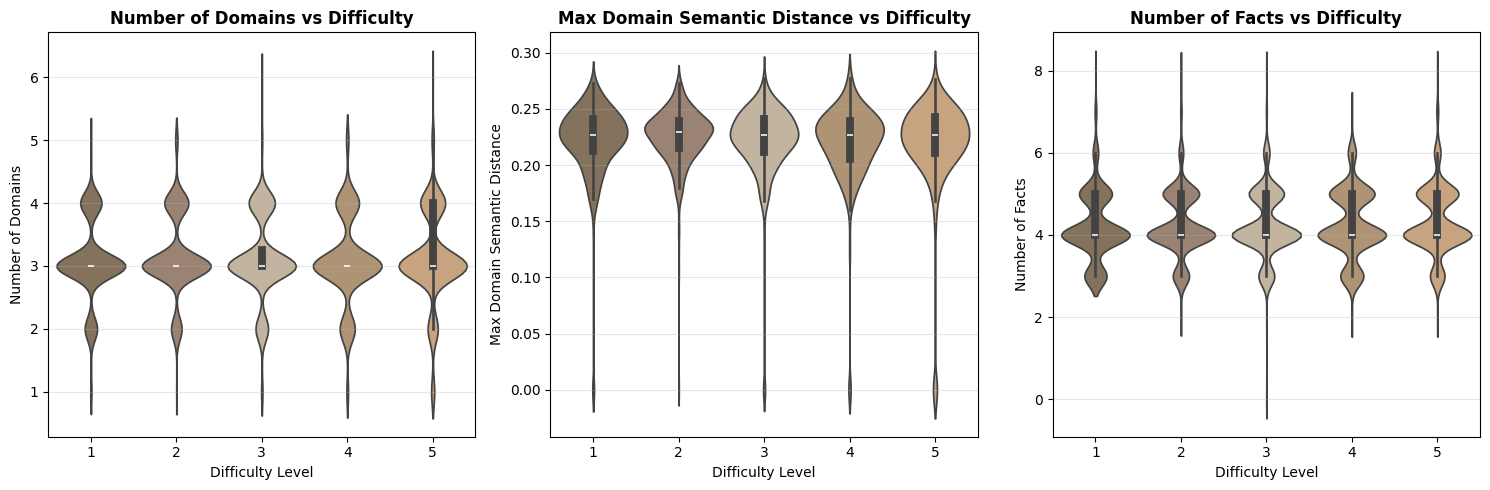

Correlation summary statistics:

Pearson correlation with difficulty:
  num_domains: 0.007
  max_domain_semdis: -0.052
  num_knowledge: 0.047


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert analysis_data to DataFrame
df = pd.DataFrame(analysis_data)

# Define earthly color palette (browns, tans, greens, terra)
earthly_palette = ["#8B7355", "#A0826D", "#C9B59A", "#B8956A", "#D4A373"]

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Number of Domains vs Difficulty
sns.violinplot(data=df, x="difficulty", y="num_domains", ax=axes[0], palette=earthly_palette)
axes[0].set_title("Number of Domains vs Difficulty", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Difficulty Level")
axes[0].set_ylabel("Number of Domains")
axes[0].grid(axis="y", alpha=0.3)

# Plot 2: Max Domain Semantic Distance vs Difficulty
sns.violinplot(data=df, x="difficulty", y="max_domain_semdis", ax=axes[1], palette=earthly_palette)
axes[1].set_title("Max Domain Semantic Distance vs Difficulty", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Difficulty Level")
axes[1].set_ylabel("Max Domain Semantic Distance")
axes[1].grid(axis="y", alpha=0.3)

# Plot 3: Number of Knowledge vs Difficulty
sns.violinplot(data=df, x="difficulty", y="num_knowledge", ax=axes[2], palette=earthly_palette)
axes[2].set_title("Number of Facts vs Difficulty", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Difficulty Level")
axes[2].set_ylabel("Number of Facts")
axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/difficulty_correlations.pdf", dpi=360, bbox_inches="tight")
plt.show()

print("Correlation summary statistics:")
print(f"\nPearson correlation with difficulty:")
print(f"  num_domains: {df['num_domains'].corr(df['difficulty']):.3f}")
print(f"  max_domain_semdis: {df['max_domain_semdis'].corr(df['difficulty']):.3f}")
print(f"  num_knowledge: {df['num_knowledge'].corr(df['difficulty']):.3f}")